# Waveform Class
Generic parameterised waveform classes for optogenetic stimulation.
Designed to slot into a simulation-based optimisation loop: the waveform is
passed to a simulation runner, a PSTH is computed, and waveform parameters are
adjusted to minimise the difference from a target PSTH.

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, differential_evolution
from abc import ABC, abstractmethod

In [32]:
class Waveform(ABC):
    """
    Abstract base class for parameterised waveforms.

    Subclasses must implement:
      - __call__(t)       : evaluate waveform at time points t
      - to_params()       : return current parameters as a flat numpy array
      - from_params(params): classmethod — construct instance from flat param array

    The optimise() method handles simulation-based optimisation: it wraps an
    arbitrary objective callable (waveform -> scalar) and passes it to
    scipy.optimize, keeping simulation logic entirely outside this class.
    """

    @abstractmethod
    def __call__(self, t: np.ndarray) -> np.ndarray:
        ...

    @abstractmethod
    def to_params(self) -> np.ndarray:
        """Return current parameters as a flat numpy array (initial guess for optimiser)."""
        ...

    @classmethod
    @abstractmethod
    def from_params(cls, params: np.ndarray):
        """Construct an instance from a flat parameter array."""
        ...

    def optimise(self, objective_fn, method='Nelder-Mead', bounds=None, **kwargs):
        """
        Optimise waveform parameters against a simulation-based objective.

        Parameters
        ----------
        objective_fn : callable(waveform) -> float
            Takes a Waveform instance, runs the simulation, and returns a scalar
            loss (e.g. MSE between simulated PSTH and target PSTH).
        method : str
            scipy.optimize.minimize method. 'Nelder-Mead' works well for
            gradient-free black-box objectives. Use 'L-BFGS-B' with bounds if
            you have a differentiable proxy, or switch to differential_evolution
            for a global search.
        bounds : sequence of (min, max) pairs, optional
            One per parameter. Required for bounded methods.

        Returns
        -------
        result_waveform : Waveform
            New instance with optimised parameters.
        opt_result : OptimizeResult
            Full scipy result object (check opt_result.success, .fun, .nit).
        """
        def _objective(params):
            wf = self.from_params(params)
            return objective_fn(wf)

        opt_result = minimize(_objective, self.to_params(),
                              method=method, bounds=bounds, **kwargs)
        return self.from_params(opt_result.x), opt_result

    def plot(self, t: np.ndarray, ax=None, **kwargs):
        if ax is None:
            _, ax = plt.subplots()
        ax.plot(t, self(t), **kwargs)
        return ax

In [33]:
class GaussianWaveform(Waveform):
    """A * exp( -(t - mu)^2 / (2*sigma^2) ) + baseline.  Always >= 0 when A >= 0."""

    def __init__(self, amplitude=1.0, mu=0.0, sigma=1.0, baseline=0.0):
        self.amplitude = amplitude
        self.mu = mu
        self.sigma = sigma
        self.baseline = baseline

    def __call__(self, t):
        return self.amplitude * np.exp(-0.5 * ((t - self.mu) / self.sigma) ** 2) + self.baseline

    def to_params(self):
        return np.array([self.amplitude, self.mu, self.sigma, self.baseline])

    @classmethod
    def from_params(cls, params):
        return cls(*params)

    def __repr__(self):
        return (f"GaussianWaveform(A={self.amplitude:.3g}, mu={self.mu:.3g}, "
                f"sigma={self.sigma:.3g}, baseline={self.baseline:.3g})")


class SquareWaveform(Waveform):
    """
    Top-hat pulse with smooth sigmoid edges.
    amplitude inside [t_on, t_off], baseline elsewhere.
    """

    def __init__(self, amplitude=1.0, t_on=0.0, t_off=1.0, baseline=0.0, steepness=50.0):
        self.amplitude = amplitude
        self.t_on = t_on
        self.t_off = t_off
        self.baseline = baseline
        self.steepness = steepness

    def __call__(self, t):
        rise = 1 / (1 + np.exp(-self.steepness * (t - self.t_on)))
        fall = 1 / (1 + np.exp(-self.steepness * (self.t_off - t)))
        return self.amplitude * rise * fall + self.baseline

    def to_params(self):
        return np.array([self.amplitude, self.t_on, self.t_off, self.baseline, self.steepness])

    @classmethod
    def from_params(cls, params):
        return cls(*params)

    def __repr__(self):
        return (f"SquareWaveform(A={self.amplitude:.3g}, t_on={self.t_on:.3g}, "
                f"t_off={self.t_off:.3g}, baseline={self.baseline:.3g})")


class PolynomialWaveform(Waveform):
    """
    Polynomial pulse windowed by an asymmetric (split) Gaussian envelope.

        envelope(t) = exp(-0.5 * ((t - mu) / sigma_rise)^2)   for t < mu
                      exp(-0.5 * ((t - mu) / sigma_fall)^2)   for t >= mu

        y(t) = polyval(coeffs, (t - mu) / sigma_rise) * envelope(t) + baseline

    sigma_rise and sigma_fall independently set the rise and decay timescales.
    The polynomial modulates the shape between them; its constant term (coeffs[-1])
    sets the peak amplitude.

    Non-negativity:
        The waveform has no built-in clip. Enforce non-negativity by adding a
        soft penalty in the objective function:

            def objective(waveform):
                y = waveform(t_stim)
                loss  = ...                                  # your PSTH loss
                loss += penalty_weight * np.mean(np.clip(-y, 0, None) ** 2)
                return loss

        A penalty_weight of 1e3–1e5 relative to the PSTH loss scale works well.
        Hard-clipping in __call__ is wrong here: it hides the violation from the
        optimizer, which then happily sits on the clipped boundary.

    Bounds to pass to optimise():
        sigma_rise > 0, sigma_fall > 0, baseline >= 0.
    """

    def __init__(self, coeffs=(1.0,), mu=0.0, sigma_rise=1.0, sigma_fall=1.0, baseline=0.0):
        self.coeffs = list(coeffs)
        self.mu = mu
        self.sigma_rise = sigma_rise
        self.sigma_fall = sigma_fall
        self.baseline = baseline

    def __call__(self, t):
        t = np.asarray(t, dtype=float)
        envelope = np.where(
            t < self.mu,
            np.exp(-0.5 * ((t - self.mu) / self.sigma_rise) ** 2),
            np.exp(-0.5 * ((t - self.mu) / self.sigma_fall) ** 2),
        )
        t_norm = (t - self.mu) / self.sigma_rise
        return np.polyval(self.coeffs, t_norm) * envelope + self.baseline

    def to_params(self):
        return np.array(self.coeffs + [self.mu, self.sigma_rise, self.sigma_fall, self.baseline])

    @classmethod
    def from_params(cls, params):
        return cls(coeffs=params[:-4], mu=params[-4],
                   sigma_rise=params[-3], sigma_fall=params[-2], baseline=params[-1])

    def __repr__(self):
        return (f"PolynomialWaveform(degree={len(self.coeffs)-1}, mu={self.mu:.3g}, "
                f"sigma_rise={self.sigma_rise:.3g}, sigma_fall={self.sigma_fall:.3g}, "
                f"baseline={self.baseline:.3g})")

## Simulation-based optimisation demo
The optimisation loop structure is:

```
for each candidate waveform (proposed by the optimiser):
    1. evaluate waveform on stimulus time axis  →  stim(t)
    2. run_simulation(stim)                     →  psth
    3. loss = compare(psth, target_psth)        →  scalar
```

The `Waveform.optimise(objective_fn)` method handles the parameter ↔ array
conversion so `objective_fn` just receives a ready-to-use `Waveform` instance.

Min waveform value: 0.0039


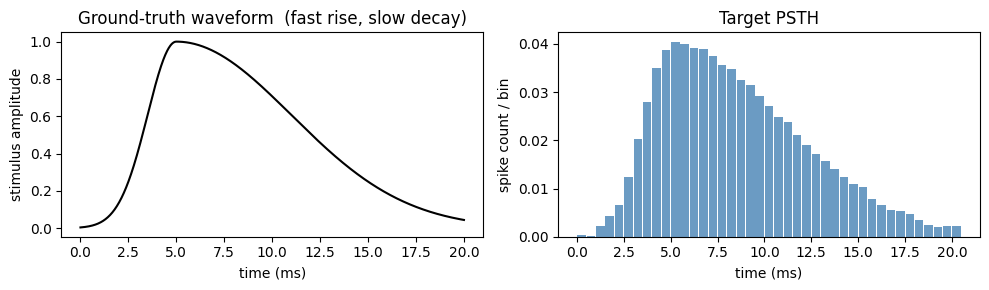

In [34]:
rng = np.random.default_rng(42)

# --- Time axes ---
t_stim = np.linspace(0, 20, 1000)       # ms, stimulus time axis
bin_edges = np.arange(0, 21, 0.5)       # 0.5 ms PSTH bins
t_psth = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# --- Mock simulation runner (replace with your Brian2 / model call) ---
def run_simulation(waveform: Waveform) -> np.ndarray:
    """
    Placeholder for the real model. Replace the body with your simulation call.
    Contract: receives a Waveform, returns a PSTH array aligned to t_psth.
    """
    stim = waveform(t_stim)
    rate = np.clip(stim, 0, None) * 80.0    # Hz

    dt_bin = bin_edges[1] - bin_edges[0]
    psth = np.array([
        rate[(t_stim >= bin_edges[i]) & (t_stim < bin_edges[i + 1])].mean() * dt_bin / 1000
        for i in range(len(bin_edges) - 1)
    ])
    return psth

# --- Ground truth: degree-0 polynomial (constant amplitude) with fast rise / slow decay ---
# Using coeffs=[1.0] keeps the waveform naturally non-negative everywhere.
# Shape asymmetry comes entirely from sigma_rise vs sigma_fall.
true_waveform = PolynomialWaveform(
    coeffs=[1.0],
    mu=5.0, sigma_rise=1.5, sigma_fall=6.0, baseline=0.0
)

print(f"Min waveform value: {true_waveform(t_stim).min():.4f}")

target_psth = run_simulation(true_waveform)
target_psth += rng.normal(0, 5e-4, size=target_psth.shape)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(t_stim, true_waveform(t_stim), 'k')
axes[0].set_xlabel('time (ms)')
axes[0].set_ylabel('stimulus amplitude')
axes[0].set_title('Ground-truth waveform  (fast rise, slow decay)')
axes[1].bar(t_psth, target_psth, width=0.45, color='steelblue', alpha=0.8)
axes[1].set_xlabel('time (ms)')
axes[1].set_ylabel('spike count / bin')
axes[1].set_title('Target PSTH')
plt.tight_layout()
plt.show()

In [35]:
PENALTY_WEIGHT = 1e4   # scale relative to your PSTH loss; tune if needed

def psth_mse(waveform: Waveform) -> float:
    y = waveform(t_stim)
    psth = run_simulation(waveform)

    loss = np.mean((psth - target_psth) ** 2)

    # Soft non-negativity penalty: penalises any region where the waveform
    # dips below zero.  The optimizer can see this gradient and is pushed away
    # from the infeasible region, unlike hard-clipping which hides the violation.
    negativity = np.mean(np.clip(-y, 0, None) ** 2)
    loss += PENALTY_WEIGHT * negativity

    return float(loss)

# Initial guess: symmetric, wrong timescale
init_waveform = PolynomialWaveform(
    coeffs=[0.0, 0.0, 0.5],
    mu=8.0, sigma_rise=3.0, sigma_fall=3.0, baseline=0.0
)

print(f"Initial loss: {psth_mse(init_waveform):.6f}")

result_waveform, opt = init_waveform.optimise(
    psth_mse,
    method='Nelder-Mead',
    options={'maxiter': 5000, 'xatol': 1e-6, 'fatol': 1e-9, 'disp': True},
)

print(f"\nOptimised loss: {opt.fun:.6f}  ({opt.nit} iterations, success={opt.success})")
print(f"Min waveform value: {result_waveform(t_stim).min():.4f}  (should be >= 0)")
print("\nTrue waveform:     ", true_waveform)
print("Optimised waveform:", result_waveform)

Initial loss: 0.000179
Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 1611
         Function evaluations: 2428

Optimised loss: 0.000000  (1611 iterations, success=True)
Min waveform value: 0.0046  (should be >= 0)

True waveform:      PolynomialWaveform(degree=0, mu=5, sigma_rise=1.5, sigma_fall=6, baseline=0)
Optimised waveform: PolynomialWaveform(degree=2, mu=5.04, sigma_rise=1.49, sigma_fall=5.69, baseline=0.00114)


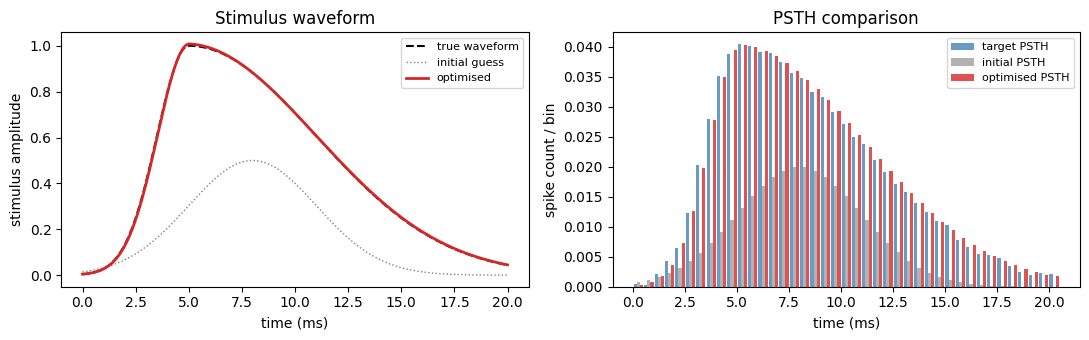

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

ax = axes[0]
ax.plot(t_stim, true_waveform(t_stim), 'k--', lw=1.5, label='true waveform')
ax.plot(t_stim, init_waveform(t_stim), color='gray', lw=1, ls=':', label='initial guess')
ax.plot(t_stim, result_waveform(t_stim), color='tab:red', lw=2, label='optimised')
ax.set_xlabel('time (ms)')
ax.set_ylabel('stimulus amplitude')
ax.set_title('Stimulus waveform')
ax.legend(fontsize=8)

ax = axes[1]
w = 0.15
ax.bar(t_psth - w, target_psth,                  width=w, color='steelblue', alpha=0.8, label='target PSTH')
ax.bar(t_psth,     run_simulation(init_waveform), width=w, color='gray',     alpha=0.6, label='initial PSTH')
ax.bar(t_psth + w, run_simulation(result_waveform), width=w, color='tab:red', alpha=0.8, label='optimised PSTH')
ax.set_xlabel('time (ms)')
ax.set_ylabel('spike count / bin')
ax.set_title('PSTH comparison')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()